In [1]:
# all imports
import sys
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import squareform

_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config, analysis, plots, data_utils

DATA_DIR = config.DATA_DIR
TRAIN_PATH = config.TRAIN_PATH
FIGURES_DIR = config.FIGURES_DIR

![alt text](../docs/figures/feature_count_by_family.png)

## 1 - Non-Null metrics

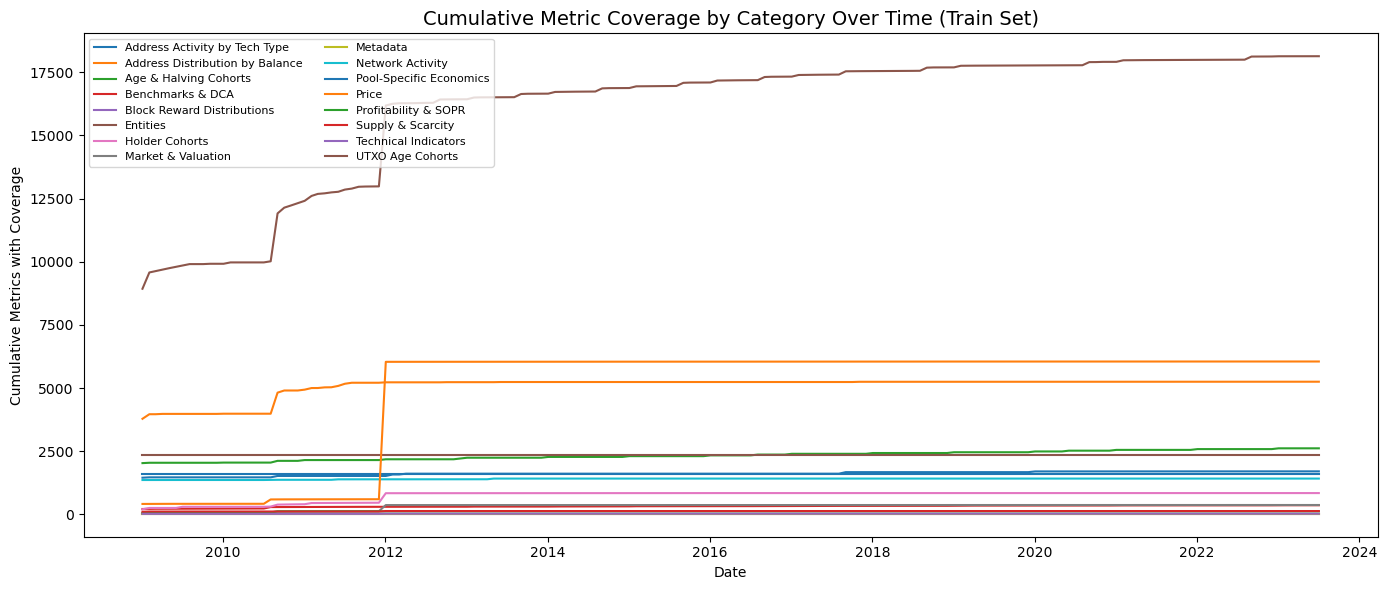

In [2]:
# Find first coverage date per metric (no nulls in data, so first date = metric start date)
coverage = (
    pl.scan_parquet(TRAIN_PATH)
    .group_by("metric")
    .agg(pl.col("day_utc").min().alias("first_date"))
    .collect()
    .with_columns(
        pl.col("metric").map_elements(analysis.assign_category, return_dtype=pl.String).alias("category")
    )
    .sort("first_date")
)

# Build cumulative count per category over time — sample at monthly intervals
all_dates = pl.date_range(
    coverage["first_date"].min(), coverage["first_date"].max(),
    interval="1mo", eager=True
)

rows = []
for cat in coverage["category"].unique().sort().to_list():
    cat_dates = coverage.filter(pl.col("category") == cat)["first_date"].sort()
    for d in all_dates:
        count = (cat_dates <= d).sum()
        rows.append({"date": d, "category": cat, "cumulative_metrics": count})

cumulative_df = pl.DataFrame(rows)

fig, ax = plt.subplots(figsize=(14, 6))
for cat, grp in cumulative_df.to_pandas().groupby("category"):
    ax.plot(grp["date"], grp["cumulative_metrics"], label=cat)
ax.set_title("Cumulative Metric Coverage by Category Over Time (Train Set)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Metrics with Coverage")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
# plt.savefig("../docs/figures/fig_cumulative_metric_coverage.png")
plt.show()

## 2 - Bitcoin price history with halving epochs

|Event|Date	|Block reward|
|---|---|---|
|1st halving|28 November 2012|25 BTC|
|2nd halving|9 July 2016|12.5 BTC|
|3rd halving|11 May 2020|6.25 BTC|
|4th halving|0 April 2024|3.125 BTC|

1. `active_price` is not spot price
active_price is an on-chain metric — it's the average acquisition price of coins that have moved recently (the "active" subset of supply). It's a cost-basis signal, not a market price. Using it would produce a smoothed, lagging valuation, not the actual trading price.

2. `price_close` likely has gaps in early history
Bitcoin had no formal exchange price until late 2010 (Mt. Gox launched July 2010). A price_close metric sourced from exchange data would have nulls or no rows for 2009–mid 2010. market_cap and supply_btc are derivable from the blockchain itself, so they exist from block 1 (January 2009) onward.

3. `market_cap / supply_btc` is mathematically equivalent to spot price
By definition: market_cap = price × supply
so, price = market_cap / supply_btc
This gives the same result as price_close wherever exchange data exists, but also works before exchanges existed.

The derivation was chosen for full historical coverage back to 2009, which is necessary for the halving epoch chart spanning all four epochs.

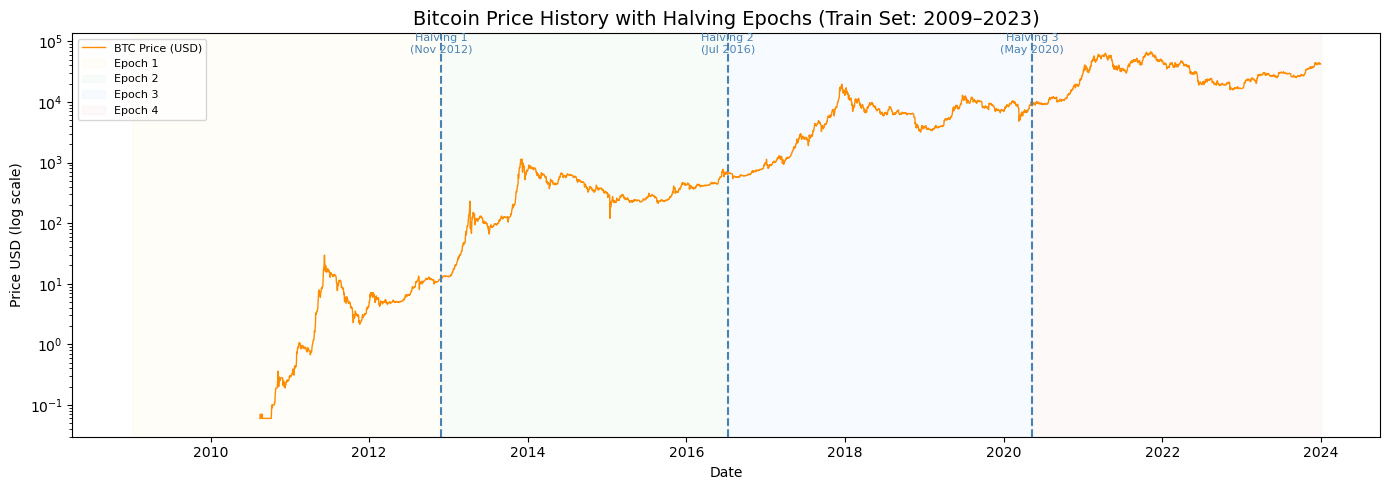

In [3]:
price_raw = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["market_cap", "supply_btc"]))
    .collect()
    .pivot(values="value", index="day_utc", on="metric")
    .sort("day_utc")
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .filter(pl.col("price_usd").is_finite() & (pl.col("price_usd") > 0))
)

HALVINGS = [
    ("Halving 1\n(Nov 2012)", "2012-11-28"),
    ("Halving 2\n(Jul 2016)", "2016-07-09"),
    ("Halving 3\n(May 2020)", "2020-05-11"),
]

plots.plot_price_history_with_halvings(price_raw.to_pandas(), halvings=HALVINGS, save_path=FIGURES_DIR / "fig_price_history.png") 

## 3 - Metric coverage heatmap by category

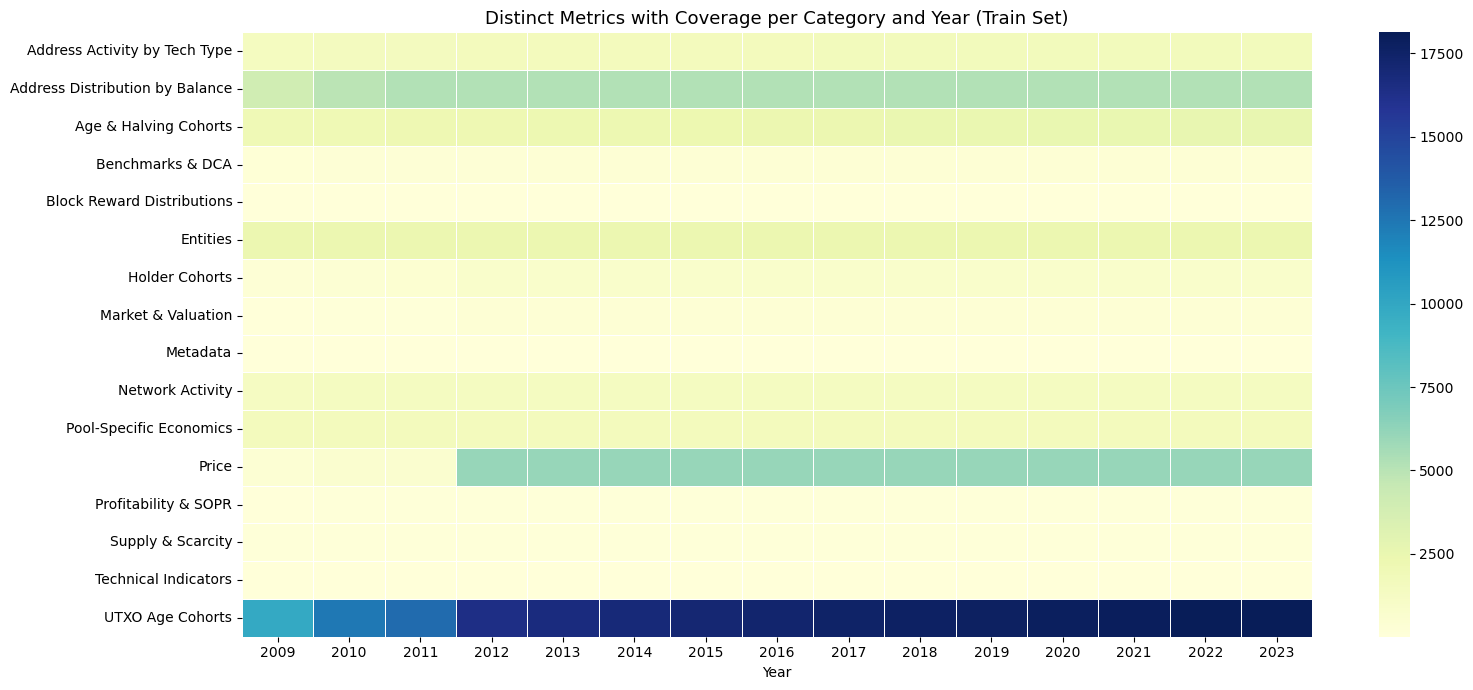

In [4]:
# For each metric, find which years it has data
years_df = (
    pl.scan_parquet(TRAIN_PATH)
    .select("day_utc", "metric")
    .with_columns(pl.col("day_utc").dt.year().alias("year"))
    .group_by(["metric", "year"])
    .agg(pl.len().alias("n_rows"))  # just confirm presence
    .collect()
    .with_columns(
        pl.col("metric").map_elements(analysis.assign_category, return_dtype=pl.String).alias("category")
    )
)

# Count distinct metrics per (category, year)
heatmap_data = (
    years_df
    .group_by(["category", "year"])
    .agg(pl.col("metric").n_unique().alias("n_metrics"))
    .sort(["category", "year"])
    .to_pandas()
    .pivot(index="category", columns="year", values="n_metrics")
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    annot=False,
    fmt="d",
    ax=ax,
)
ax.set_title("Distinct Metrics with Coverage per Category and Year (Train Set)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4 - Correlation dendrogram of signal features

Why Pearson's correlation instead of Euclidean distance
| Property | Pearson (1 − r) | Euclidean (scaled)|
|---|---|---|
| Measures | Shape similarity of time series | Distance between scaled values |
| Scale-invariant | Yes — naturally | Only after StandardScaler |
| Captures redundancy | Directly (r=0.99 -> nearly identical) | Indirectly, as a proxy |
| What gets clustered together | Metrics that move together | Metrics with similar value ranges |
| Suited for multicollinearity detection | Yes | Partial |

Shape after cleaning: (5471, 23)


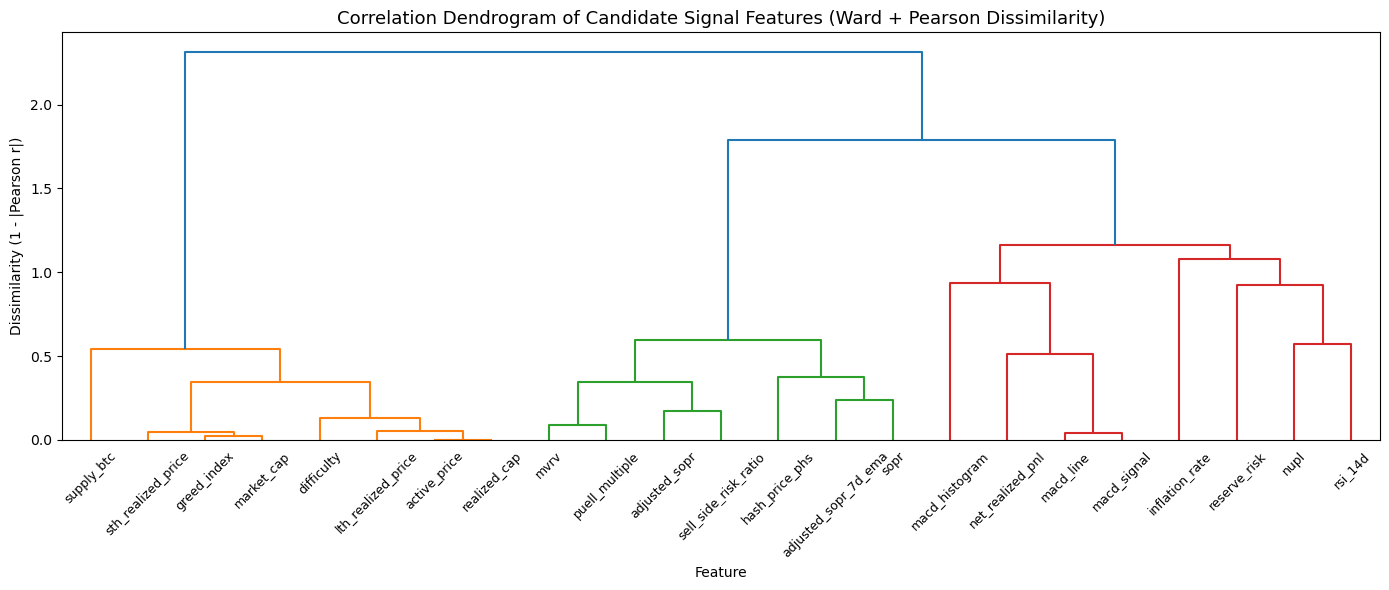

In [5]:
SIGNAL_METRICS = [
    "mvrv", "nupl", "sopr", "adjusted_sopr", "adjusted_sopr_7d_ema",
    "rsi_14d", "macd_line", "macd_signal", "macd_histogram",
    "market_cap", "realized_cap", "active_price",
    "greed_index", "reserve_risk", "puell_multiple",
    "net_realized_pnl", "sell_side_risk_ratio",
    "hash_price_phs", "difficulty",
    "supply_btc", "inflation_rate",
    "sth_realized_price", "lth_realized_price",
]

wide         = data_utils.load_metric_wide(TRAIN_PATH, pl.col("metric").is_in(SIGNAL_METRICS))

print(f"Shape after cleaning: {wide.shape}")  # sanity check — should have rows and columns

corr, Z      = analysis.compute_correlation_linkage(wide)
plots.plot_dendrogram(Z, corr.columns.tolist(), "Correlation Dendrogram of Candidate Signal Features (Ward + Pearson Dissimilarity)")

## 5 - MVRV / NUPL / SOPR distributions across market 

These three metrics are the core market cycle indicators the project relies on to identify when Bitcoin is undervalued. The violin plot answers a critical question before any modeling: do these signals actually behave differently across cycles, and are they consistent enough to be useful?

Specifically it helps in three ways:

1. Validates the signals are cycle-aware
If MVRV, NUPL, and SOPR distributions shift predictably across epochs (e.g. lower median in early epochs, higher in late bull markets), it confirms they carry cycle timing information.

2. Identifies where thresholds make sense
The quartile lines inside each violin show where values cluster. For example, MVRV < 1 is historically a strong accumulation signal. If the Epoch 1/2 violins show a wide low-value distribution and Epoch 3/4 are higher and tighter, that confirms the threshold is meaningful and stable.

3. Catches degenerate metrics early
If a metric's distribution looks the same across all four epochs (flat, no shift), it has no discriminative power for cycle detection and should be dropped before feature selection.



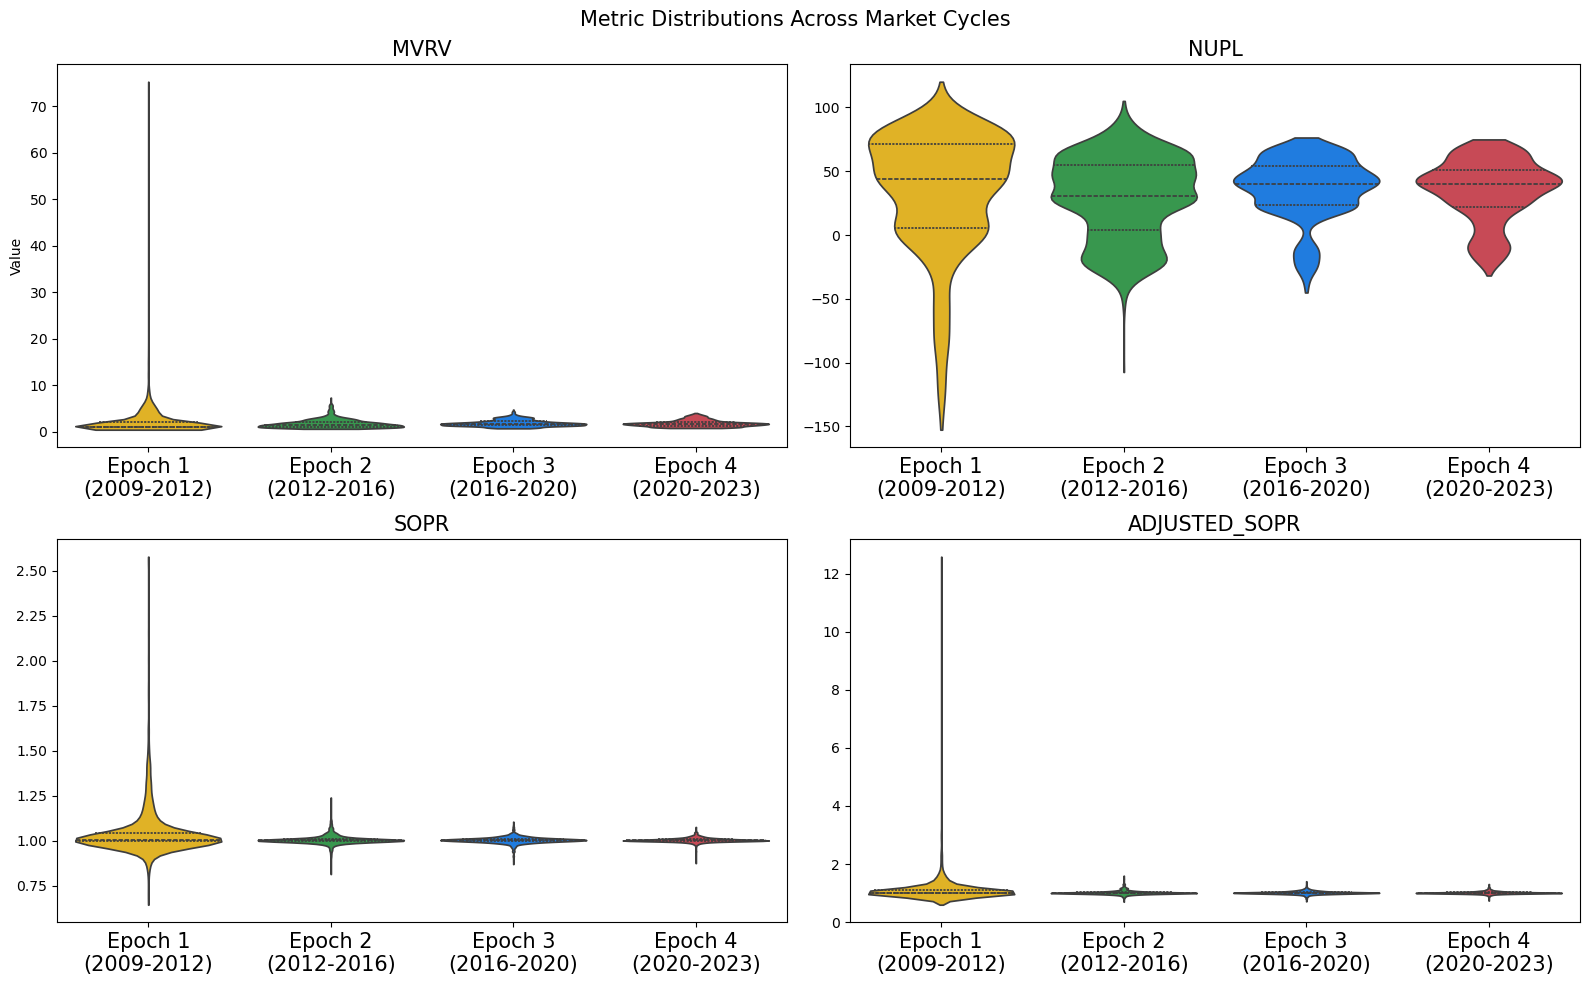

In [6]:
CYCLE_METRICS = ["mvrv", "nupl", "sopr", "adjusted_sopr"]

cycle_bounds = [
    ("Epoch 1\n(2009-2012)", "2009-01-03", "2012-11-27"),
    ("Epoch 2\n(2012-2016)", "2012-11-28", "2016-07-08"),
    ("Epoch 3\n(2016-2020)", "2016-07-09", "2020-05-10"),
    ("Epoch 4\n(2020-2023)", "2020-05-11", "2023-12-31"),
]

cycle_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(CYCLE_METRICS))
    .collect()
    .to_pandas()
)
cycle_df["day_utc"] = pd.to_datetime(cycle_df["day_utc"])

def label_cycle(d):
    for label, start, end in cycle_bounds:
        if pd.Timestamp(start) <= d <= pd.Timestamp(end):
            return label
    return "Other"

cycle_df["cycle"] = cycle_df["day_utc"].apply(label_cycle)
cycle_df = cycle_df[cycle_df["cycle"] != "Other"]
cycle_df["value"] = pd.to_numeric(cycle_df["value"], errors="coerce")
cycle_df = cycle_df.dropna(subset=["value"])

cycle_order = [c[0] for c in cycle_bounds]

plots.plot_cycle_violin(cycle_df, CYCLE_METRICS, cycle_order, save_path=FIGURES_DIR / "fig_cycle_violin_plots.png")